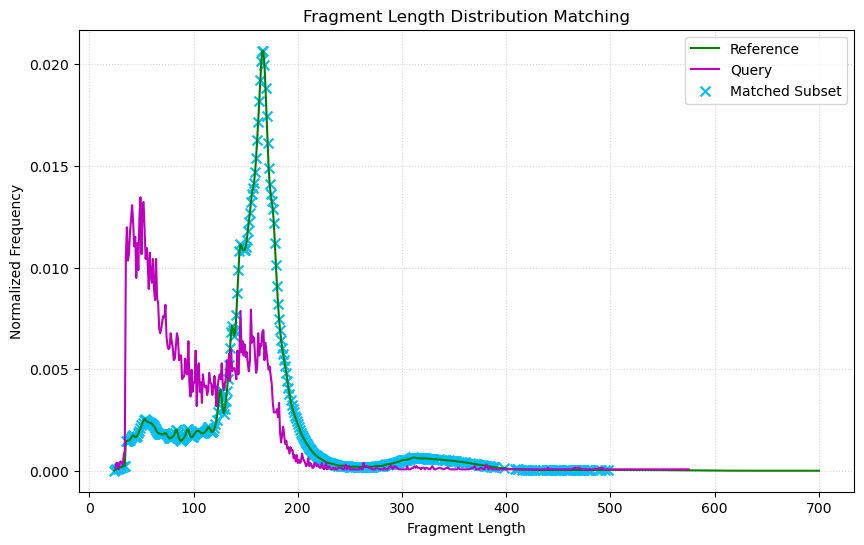

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ref_df = pd.read_csv('reference.hist', sep='\t', header=None, low_memory=False)
query_col = ['chromosome', 'start', 'end', 'other1', 'other2', 'symbol']
col = ['chromosome', 'start', 'end', 'other1', 'other2', 'symbol']
query_df = pd.read_csv('query.bed.gz', sep='\t',header=None, compression='gzip',names=col,low_memory=False)

query_len = query_df['end']-query_df['start']
query_counts = pd.Series(query_len).value_counts().sort_index()
query_norm = query_counts / query_counts.sum()

bin_edges = np.arange(0, 510, 10)
bin_name = [f"{i}-{i+9}bp" for i in range(0, 500, 10)]

ref_df['bin_size'] = pd.cut(ref_df[0], bins=bin_edges, labels=bin_name, right=False)
query_df['fragment_length'] = query_df['end'] - query_df['start']
query_df['bin_size'] = pd.cut(query_df['fragment_length'], bins=bin_edges, labels=bin_name, right=False)

ref_bin_counts = ref_df['bin_size'].value_counts().sort_index()
query_bin_counts = query_df['bin_size'].value_counts().sort_index()


que_fragments = []
for bin in bin_name:
    ref_count = ref_bin_counts.get(bin, 0)
    query_count = query_bin_counts.get(bin, 0)

    que_size = min(ref_count, query_count)
    
    if (que_size > 0):
        bin_frag = ref_df[ref_df['bin_size'] == bin]
        que = bin_frag.sample(n=que_size, random_state=42)
        que_fragments.append(que)


final_val = pd.concat(que_fragments).sort_values(0)
plt.figure(figsize=(10, 6))
plt.plot(ref_df[0], ref_df[1], 'g-', label='Reference')
plt.plot(query_counts.index, query_norm, 'm-', label='Query')
plt.scatter(final_val[0], final_val[1], c='deepskyblue', marker='x', s=50, label='Matched Subset')
plt.legend()
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.title('Fragment Length Distribution Matching')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()